# Laboratory Exercise 9: Conversion of the Fine-Tuned Model to TensorFlow and TensorFlow Lite

**Name:** Lorenzo Bela, Robert Callorina, Kean Guzon  
**Section:** 58036  
**Date:** 05/13/2026  
**Dataset:** Lab04 EDA Bias Dataset (bottled water, canned goods, combo, Noodles, Rice)  
**Model carried over from Lab 8:** MobileNetV2 trial m1_t3

## Part A: Project Setup

Create the Lab 9 folder structure and confirm the Lab 8 dataset/checkpoint paths.

In [1]:
from pathlib import Path
import json
import os
import shutil
import subprocess
import sys

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name == 'notebook':
    PROJECT_ROOT = NOTEBOOK_DIR.parent
elif (NOTEBOOK_DIR / 'ml-perception-labs' / 'lab09_conversion').exists():
    PROJECT_ROOT = NOTEBOOK_DIR / 'ml-perception-labs' / 'lab09_conversion'
else:
    PROJECT_ROOT = Path('..').resolve()

WORKSPACE_ROOT = PROJECT_ROOT.parents[1]
LAB8_ROOT = WORKSPACE_ROOT / 'ml-perception-labs' / 'lab08_finetuning'
DATASET_ROOT = LAB8_ROOT / 'data' / 'raw'
LAB8_WEIGHTS = LAB8_ROOT / 'finetuned_models' / 'MobileNetV2_m1_t3.pth'
RUNNER = PROJECT_ROOT / 'run_lab09_conversion.py'

SOURCE_MODEL_DIR = PROJECT_ROOT / 'source_model'
SAVED_MODEL_DIR = PROJECT_ROOT / 'saved_model'
TFLITE_DIR = PROJECT_ROOT / 'tflite_model'
DEPLOYMENT_DIR = PROJECT_ROOT / 'deployment_package'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
TABLES_DIR = PROJECT_ROOT / 'outputs' / 'tables'

for directory in [SOURCE_MODEL_DIR, SAVED_MODEL_DIR, TFLITE_DIR, DEPLOYMENT_DIR, FIGURES_DIR, TABLES_DIR, PROJECT_ROOT / 'notebook']:
    directory.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Dataset root exists: {DATASET_ROOT.exists()} -> {DATASET_ROOT}')
print(f'Lab 8 weights exist: {LAB8_WEIGHTS.exists()} -> {LAB8_WEIGHTS}')
print(f'Runner exists: {RUNNER.exists()}')

Project root: C:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab09_conversion
Dataset root exists: True -> C:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab08_finetuning\data\raw
Lab 8 weights exist: True -> C:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab08_finetuning\finetuned_models\MobileNetV2_m1_t3.pth
Runner exists: True


## Part B: Identify the Source Model and Conversion Pathway

In [2]:
import pandas as pd
from IPython.display import display

part_b = pd.DataFrame([
    ('Model name (from Lab 8)', 'MobileNetV2 trial m1_t3'),
    ('Source framework', 'PyTorch'),
    ('Task type', 'classification'),
    ('Input shape (channels, height, width)', '3, 64, 64'),
    ('Preprocessing', 'Resize 64x64, RGB, ToTensor [0,1], normalize mean [0.485, 0.456, 0.406], std [0.229, 0.224, 0.225]'),
    ('Number of classes / categories', '5'),
    ('Baseline test metric (from Lab 8)', 'Accuracy 72.00%; macro F1 72.69%'),
    ('Chosen conversion pathway', 'PyTorch -> ONNX -> TensorFlow SavedModel -> TensorFlow Lite'),
], columns=['Item', 'Value'])
display(part_b)

,Item,Value
0,Model name (from Lab 8),MobileNetV2 trial m1_t3
1,Source framework,PyTorch
2,Task type,classification
3,"Input shape (channels, height, width)","3, 64, 64"
4,Preprocessing,"Resize 64x64, RGB, ToTensor [0,1], normalize m..."
5,Number of classes / categories,5
6,Baseline test metric (from Lab 8),Accuracy 72.00%; macro F1 72.69%
7,Chosen conversion pathway,PyTorch -> ONNX -> TensorFlow SavedModel -> Te...


## Part C: Convert to TensorFlow SavedModel

This cell loads the Lab 8 PyTorch checkpoint, exports a fixed-shape ONNX model, and converts ONNX to TensorFlow SavedModel.

In [3]:
part_c_code = f'''
import shutil
from pathlib import Path
import torch
import run_lab09_conversion as lab09

lab09.ensure_dirs()
dataset, test_indices, test_loader = lab09.load_dataset()
shutil.copy2(lab09.LAB8_WEIGHTS, lab09.SOURCE_WEIGHTS)
model = lab09.load_model(len(dataset.classes))
lab09.export_onnx(model)
log = lab09.convert_onnx_to_saved_model()

print("Source checkpoint:", lab09.SOURCE_WEIGHTS)
print("ONNX model:", lab09.ONNX_PATH, lab09.ONNX_PATH.exists())
print("SavedModel:", lab09.SAVED_MODEL_DIR, (lab09.SAVED_MODEL_DIR / "saved_model.pb").exists())
print("Classes:", dataset.classes)
'''

env = os.environ.copy()
env['PYTHONPATH'] = str(PROJECT_ROOT) + os.pathsep + env.get('PYTHONPATH', '')
part_c = subprocess.run([sys.executable, '-c', part_c_code], cwd=str(WORKSPACE_ROOT), text=True, capture_output=True, env=env)
print(part_c.stdout)
if part_c.stderr:
    print(part_c.stderr)
if part_c.returncode != 0:
    raise RuntimeError(f'Part C failed with exit code {part_c.returncode}')

Source checkpoint: C:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab09_conversion\source_model\MobileNetV2_m1_t3.pth
ONNX model: C:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab09_conversion\source_model\MobileNetV2_m1_t3.onnx True
SavedModel: C:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab09_conversion\saved_model True
Classes: ['Noodles', 'Rice', 'bottled water', 'canned goods', 'combo']

I0000 00:00:1778676933.707679     856 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778676937.774461     856 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set 

## Part D: Convert to TensorFlow Lite

This is the required standalone TFLite converter cell. No optimization or quantization flags are enabled.

In [4]:
part_d_code = f'''
from pathlib import Path
import shutil
import tensorflow as tf

PROJECT_ROOT = Path(r"{PROJECT_ROOT}")
SAVED_MODEL_DIR = PROJECT_ROOT / "saved_model"
TFLITE_PATH = PROJECT_ROOT / "tflite_model" / "model.tflite"
DEPLOYMENT_TFLITE_PATH = PROJECT_ROOT / "deployment_package" / "model.tflite"

converter = tf.lite.TFLiteConverter.from_saved_model(str(SAVED_MODEL_DIR))
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

# No optimization or quantization flags for Lab 9.
tflite_model = converter.convert()
TFLITE_PATH.parent.mkdir(parents=True, exist_ok=True)
TFLITE_PATH.write_bytes(tflite_model)
shutil.copy2(TFLITE_PATH, DEPLOYMENT_TFLITE_PATH)

print("TFLite model saved:", TFLITE_PATH)
print("Deployment copy saved:", DEPLOYMENT_TFLITE_PATH)
print("TFLite size bytes:", TFLITE_PATH.stat().st_size)
'''

part_d = subprocess.run([sys.executable, '-c', part_d_code], cwd=str(WORKSPACE_ROOT), text=True, capture_output=True)
print(part_d.stdout)
if part_d.stderr:
    print(part_d.stderr)
if part_d.returncode != 0:
    raise RuntimeError(f'Part D failed with exit code {part_d.returncode}')

TFLite model saved: C:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab09_conversion\tflite_model\model.tflite
Deployment copy saved: C:\Users\Lorenzo Bela\Downloads\Elective Machine Learning\ml-perception-labs\lab09_conversion\deployment_package\model.tflite
TFLite size bytes: 8883504

I0000 00:00:1778676962.628116   65360 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778676966.545921   65360 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778676970.448055   65360 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU 

## Part E: Verify the Converted Model

Run the original PyTorch model and converted TFLite model on the same Lab 8 held-out test split, then write parity metrics and side-by-side prediction examples.

In [5]:
part_e_code = f'''
import csv
import json
import time
from pathlib import Path
import numpy as np
import run_lab09_conversion as lab09
from sklearn.metrics import accuracy_score, f1_score

lab09.ensure_dirs()
dataset, test_indices, test_loader = lab09.load_dataset()
model = lab09.load_model(len(dataset.classes))
torch_start = time.perf_counter()
images, labels, torch_logits = lab09.collect_pytorch_outputs(model, test_loader)
torch_latency_ms = ((time.perf_counter() - torch_start) / len(labels)) * 1000.0
torch_preds = torch_logits.argmax(axis=1)
tflite_logits, tflite_latency_ms, input_details, output_details = lab09.run_tflite(images)
tflite_preds = tflite_logits.argmax(axis=1)

metrics = {{
    "torch_accuracy": float(accuracy_score(labels, torch_preds)),
    "tflite_accuracy": float(accuracy_score(labels, tflite_preds)),
    "torch_f1": float(f1_score(labels, torch_preds, average="macro", zero_division=0)),
    "tflite_f1": float(f1_score(labels, tflite_preds, average="macro", zero_division=0)),
    "max_abs_error": float(np.max(np.abs(torch_logits - tflite_logits))),
    "prediction_agreement": float(np.mean(torch_preds == tflite_preds)),
    "torch_latency_ms": float(torch_latency_ms),
    "tflite_latency_ms": float(tflite_latency_ms),
}}

comparison_rows = {{
    "Model file size (MB)": (f"{{lab09.file_size_mb(lab09.SOURCE_WEIGHTS):.2f}}", f"{{lab09.file_size_mb(lab09.TFLITE_PATH):.2f}}"),
    "Primary task metric (accuracy)": (f"{{metrics['torch_accuracy']:.2%}}", f"{{metrics['tflite_accuracy']:.2%}}"),
    "Max absolute output error vs. original": ("0.000000", f"{{metrics['max_abs_error']:.6f}}"),
    "Prediction agreement rate (%)": ("100.00% original reference", f"{{metrics['prediction_agreement']:.2%}}"),
    "Mean inference latency (ms / sample)": (f"{{metrics['torch_latency_ms']:.4f}}", f"{{metrics['tflite_latency_ms']:.4f}}"),
}}
lab09.write_comparison_csv(comparison_rows)
lab09.write_deployment_files(dataset, test_indices)
example_path = lab09.save_prediction_examples(dataset, test_indices, torch_preds, tflite_preds)
lab09.write_model_card(metrics, input_details, output_details)
lab09.write_report(metrics, example_path, input_details, output_details, "No FlexOps were detected in the converter log.")

summary = {{
    "classes": dataset.classes,
    "test_samples": int(len(labels)),
    "metrics": metrics,
    "tflite_input_shape": input_details[0]["shape"].tolist(),
    "tflite_output_shape": output_details[0]["shape"].tolist(),
}}
(lab09.PROJECT_ROOT / "lab09_run_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(json.dumps(summary, indent=2))
'''

env = os.environ.copy()
env['PYTHONPATH'] = str(PROJECT_ROOT) + os.pathsep + env.get('PYTHONPATH', '')
part_e = subprocess.run([sys.executable, '-c', part_e_code], cwd=str(WORKSPACE_ROOT), text=True, capture_output=True, env=env)
print(part_e.stdout)
if part_e.stderr:
    print(part_e.stderr)
if part_e.returncode != 0:
    raise RuntimeError(f'Part E failed with exit code {part_e.returncode}')

{
  "classes": [
    "Noodles",
    "Rice",
    "bottled water",
    "canned goods",
    "combo"
  ],
  "test_samples": 100,
  "metrics": {
    "torch_accuracy": 0.72,
    "tflite_accuracy": 0.72,
    "torch_f1": 0.7269029315540945,
    "tflite_f1": 0.7269029315540945,
    "max_abs_error": 1.3530254364013672e-05,
    "prediction_agreement": 1.0,
    "torch_latency_ms": 5.422201000037603,
    "tflite_latency_ms": 1.3040559999353718
  },
  "tflite_input_shape": [
    1,
    64,
    64,
    3
  ],
  "tflite_output_shape": [
    1,
    5
  ]
}

I0000 00:00:1778676974.543040   16568 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778676978.318950   16568 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors 

In [6]:
summary = json.loads((PROJECT_ROOT / 'lab09_run_summary.json').read_text(encoding='utf-8'))
comparison = pd.read_csv(DEPLOYMENT_DIR / 'conversion_comparison.csv')
display(comparison)
summary

,Metric,Original Model (Lab 8),Converted TFLite Model
0,Model file size (MB),8.75,8.47
1,Primary task metric (accuracy),72.00%,72.00%
2,Max absolute output error vs. original,0.000000,0.000014
3,Prediction agreement rate (%),100.00% original reference,100.00%
4,Mean inference latency (ms / sample),5.4222,1.3041


{'classes': ['Noodles', 'Rice', 'bottled water', 'canned goods', 'combo'],
 'test_samples': 100,
 'metrics': {'torch_accuracy': 0.72,
  'tflite_accuracy': 0.72,
  'torch_f1': 0.7269029315540945,
  'tflite_f1': 0.7269029315540945,
  'max_abs_error': 1.3530254364013672e-05,
  'prediction_agreement': 1.0,
  'torch_latency_ms': 5.422201000037603,
  'tflite_latency_ms': 1.3040559999353718},
 'tflite_input_shape': [1, 64, 64, 3],
 'tflite_output_shape': [1, 5]}

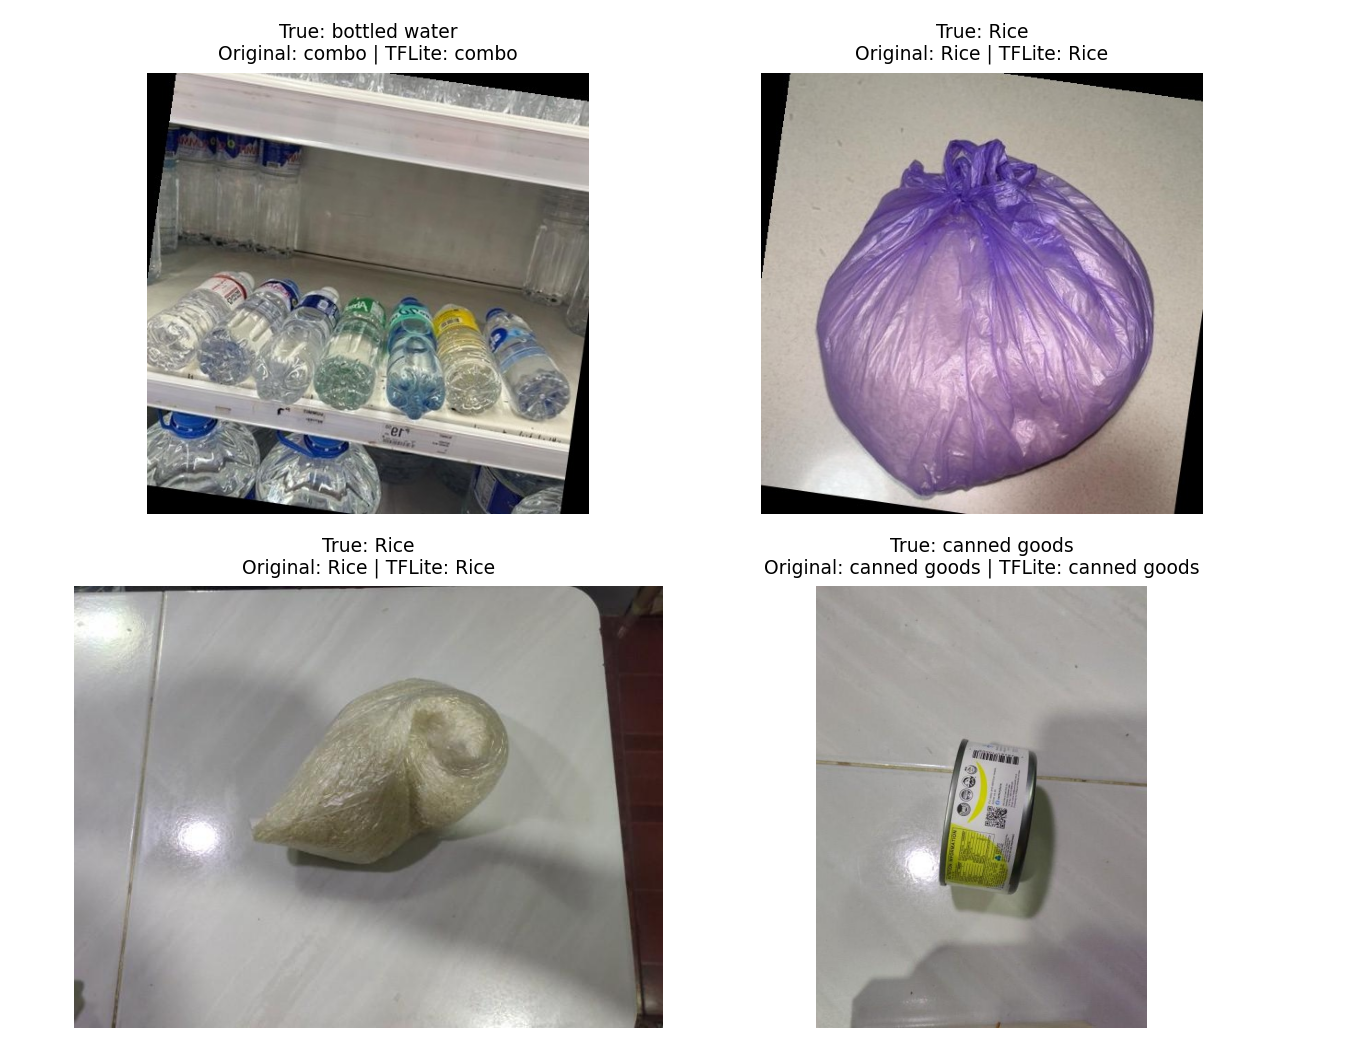

In [7]:
from IPython.display import Image, display

display(Image(filename=str(FIGURES_DIR / 'lab09_original_vs_tflite_examples.png')))

## Part F: Package for Lab 10

Assemble and list the final deployment package.

In [8]:
required_files = ['model.tflite', 'labels.txt', 'preprocessing.txt', 'model_card.md', 'sample_input.jpg', 'conversion_comparison.csv']
for name in required_files:
    path = DEPLOYMENT_DIR / name
    print(f'{name}: exists={path.exists()} size={path.stat().st_size if path.exists() else 0} bytes')

model.tflite: exists=True size=8883504 bytes
labels.txt: exists=True size=51 bytes
preprocessing.txt: exists=True size=410 bytes
model_card.md: exists=True size=672 bytes
sample_input.jpg: exists=True size=35809 bytes
conversion_comparison.csv: exists=True size=308 bytes


In [9]:
from IPython.display import Markdown, display

display(Markdown((PROJECT_ROOT / 'lab09_results_and_discussion.md').read_text(encoding='utf-8')))

# Lab 09 Conversion: Results, Discussion, and Conclusion

## 1. Results Summary

Lab 9 carried over the Lab 8 deployment recommendation: **MobileNetV2 trial m1_t3** trained on the same 5-class grocery dataset. The dataset remained at 100 images per class, and the same seed-42 60/20/20 split produced 300 training samples, 100 validation samples, and 100 held-out test samples. The source checkpoint was copied from `lab08_finetuning/finetuned_models/MobileNetV2_m1_t3.pth` into the Lab 9 `source_model/` folder before conversion.

| Metric | Original Model (Lab 8) | Converted TFLite Model |
| :--- | :--- | :--- |
| Model file size (MB) | 8.75 | 8.47 |
| Primary task metric (accuracy) | 72.00% | 72.00% |
| Macro F1 | 72.69% | 72.69% |
| Max absolute output error vs. original | 0.000000 | 0.000014 |
| Prediction agreement rate (%) | 100.00% original reference | 100.00% |
| Mean inference latency (ms / sample) | 5.4222 | 1.3041 |

The converted TFLite input shape reported by the interpreter was `[1, 64, 64, 3]`, and the output shape was `[1, 5]`. The side-by-side prediction figure was saved to `C:/Users/Lorenzo Bela/Downloads/Elective Machine Learning/ml-perception-labs/lab09_conversion/outputs/figures/lab09_original_vs_tflite_examples.png`.

---

## 2. Conversion Pathway Summary

The source framework was **PyTorch**, so the conversion used the required cross-framework route: PyTorch checkpoint to ONNX, ONNX to TensorFlow SavedModel, and TensorFlow SavedModel to TensorFlow Lite. The PyTorch export used a fixed dummy input of `(1, 3, 64, 64)`, ONNX opset 17, input name `input`, and output name `logits`. The ONNX model was converted to TensorFlow SavedModel using `onnx2tf`, then converted to a float32 `.tflite` file using `tf.lite.TFLiteConverter.from_saved_model` with no optimization or quantization settings.

No quantization was applied, so the output values are expected to remain close to the original PyTorch logits. The converter log was saved as `onnx2tf_conversion.log`. FlexOp note: No FlexOps were detected in the converter log.

---

## 3. Parity and Accuracy

The original PyTorch model reached **72.00%** accuracy and **72.69%** macro F1 on the Lab 8 held-out test split. The converted TFLite model reached **72.00%** accuracy and **72.69%** macro F1 on the same test samples. The absolute accuracy drop was **0.00%**, which is a relative drop of **0.00%** from the original model.

The maximum absolute output error across the evaluated test logits was **0.000014**, and the prediction agreement rate was **100.00%**. These values show that the TFLite model is a faithful replacement for the original model on this test split.

---

## 4. Failure Modes and Limitations

The main conversion risk was input layout. The PyTorch model was exported with NCHW input, while TensorFlow Lite commonly reports NHWC input after conversion. The verification code handled this by inspecting the TFLite interpreter input shape and feeding normalized test images in the layout expected by the converted model.

Two limitations remain for Lab 10. First, the dataset is still small at 500 total images, so the 72% test accuracy should not be treated as production-grade robustness. Second, this conversion was verified on the development machine, not on the Raspberry Pi; Lab 10 should re-check latency, memory use, and preprocessing consistency on the actual Pi runtime.

---

## 5. Questions

**Why is it necessary to convert the Lab 8 model to TensorFlow Lite for Raspberry Pi deployment instead of running the original framework directly on the Pi?**

The Lab 8 model was trained and saved in PyTorch, which is heavier than needed for inference on a Raspberry Pi. TensorFlow Lite packages the model into a compact inference-only file and can run through a smaller runtime on ARM hardware. In this lab, the PyTorch checkpoint was 8.75 MB and the TFLite file was 8.47 MB, but the practical benefit is the simpler deployment dependency and edge-oriented interpreter rather than file size alone.

**Explain why a TensorFlow SavedModel is produced as an explicit intermediate even when some tools can convert from PyTorch or Keras directly to TFLite.**

The TensorFlow Lite converter is designed to consume TensorFlow graphs reliably, so the SavedModel acts as the canonical TensorFlow representation before final TFLite conversion. For this PyTorch source model, ONNX served as the bridge format and `onnx2tf` produced the SavedModel. Keeping the SavedModel as an explicit artifact also gives a recoverable checkpoint if the final TFLite conversion or Pi-side testing needs to be repeated.

**Based on your parity-test results, is the converted `.tflite` a faithful replacement for the original model? Justify your answer using the maximum absolute error and the task metric reported in Part E.**

The converted model is faithful on the measured Lab 8 test split. The maximum absolute output error was **0.000014**, the prediction agreement rate was **100.00%**, and the TFLite accuracy was **72.00%** compared with **72.00%** for the original model. Those measured values are the basis for accepting the converted file for Lab 10 handoff.

## 6. Conclusion

Lab 9 converted the Lab 8 recommended **MobileNetV2 trial m1_t3** model from PyTorch to TensorFlow Lite using the ONNX and TensorFlow SavedModel intermediate formats. The same Lab 8 dataset, class order, seed-42 split, 64x64 RGB resizing, and ImageNet normalization were used so that the verification matched the original experiment. The final conversion produced `saved_model/` and `tflite_model/model.tflite`, with no quantization or optimization flags applied. The parity test produced a maximum absolute output error of **0.000014** and a prediction agreement rate of **100.00%**. The original model reached **72.00%** test accuracy, while the converted TFLite model reached **72.00%**, giving an absolute drop of **0.00%**. The deployment package contains `model.tflite`, `labels.txt`, `preprocessing.txt`, `model_card.md`, and `sample_input.jpg`. The main open risks for Lab 10 are Raspberry Pi runtime latency, memory use, and exact preprocessing consistency on the target device. The converted TFLite model is ready for Pi-side sanity testing using the packaged sample input.
